In [1]:
import datasets
from transformers import AutoModelForImageTextToText, AutoProcessor
import torch
import os
from peft import load_peft_weights, set_peft_model_state_dict
from PIL import Image
from models.latent_student import LatentStudent

Skipping import of cpp extensions due to incompatible torch version. Please upgrade to torch >= 2.11.0 (found 2.10.0+cu128).


In [2]:
ckpt_dir_1 = "checkpoints/stage2_decoupled_mini_student_2/step_000400"
ckpt_dir_2 = "checkpoints/stage2_decoupled_mini_student_2/step_000619"
base_model_name = "shreethar/stage1_unsloth"

In [3]:
processor = AutoProcessor.from_pretrained(base_model_name)
end_think_token_id = processor.tokenizer.convert_tokens_to_ids("</think>")

In [4]:
print("Loading base model and initializing LatentStudent...")
student = LatentStudent(
    model_name=base_model_name,
    M=6, 
    K=5,
    end_think_token_id=end_think_token_id
)


Loading base model and initializing LatentStudent...


Loading weights:   0%|          | 0/723 [00:00<?, ?it/s]

In [5]:
print("Loading LoRA weights...")
lora_weights = load_peft_weights(os.path.join(ckpt_dir_2, "student_lora"))
set_peft_model_state_dict(student.vlm, lora_weights)

Loading LoRA weights...


_IncompatibleKeys(missing_keys=['base_model.model.model.visual.patch_embed.proj.weight', 'base_model.model.model.visual.patch_embed.proj.bias', 'base_model.model.model.visual.pos_embed.weight', 'base_model.model.model.visual.blocks.0.norm1.weight', 'base_model.model.model.visual.blocks.0.norm1.bias', 'base_model.model.model.visual.blocks.0.norm2.weight', 'base_model.model.model.visual.blocks.0.norm2.bias', 'base_model.model.model.visual.blocks.0.attn.qkv.weight', 'base_model.model.model.visual.blocks.0.attn.qkv.bias', 'base_model.model.model.visual.blocks.0.attn.proj.weight', 'base_model.model.model.visual.blocks.0.attn.proj.bias', 'base_model.model.model.visual.blocks.0.mlp.linear_fc1.weight', 'base_model.model.model.visual.blocks.0.mlp.linear_fc1.bias', 'base_model.model.model.visual.blocks.0.mlp.linear_fc2.weight', 'base_model.model.model.visual.blocks.0.mlp.linear_fc2.bias', 'base_model.model.model.visual.blocks.1.norm1.weight', 'base_model.model.model.visual.blocks.1.norm1.bias', 

In [6]:
print("Loading spatial parameters...")
state = torch.load(os.path.join(ckpt_dir_2, "training_state.pt"), map_location="cpu")
student.spatial_tokens.data.copy_(state["spatial_tokens"])
student.spatial_mlp.load_state_dict(state["spatial_mlp"])

Loading spatial parameters...


<All keys matched successfully>

In [7]:
student.cuda()
student.eval()

LatentStudent(
  (vlm): PeftModelForCausalLM(
    (base_model): LoraModel(
      (model): Qwen3_5ForConditionalGeneration(
        (model): Qwen3_5Model(
          (visual): Qwen3_5VisionModel(
            (patch_embed): Qwen3_5VisionPatchEmbed(
              (proj): Conv3d(3, 1024, kernel_size=(2, 16, 16), stride=(2, 16, 16))
            )
            (pos_embed): Embedding(2304, 1024)
            (rotary_pos_emb): Qwen3_5VisionRotaryEmbedding()
            (blocks): ModuleList(
              (0-23): 24 x Qwen3_5VisionBlock(
                (norm1): LayerNorm((1024,), eps=1e-06, elementwise_affine=True)
                (norm2): LayerNorm((1024,), eps=1e-06, elementwise_affine=True)
                (attn): Qwen3_5VisionAttention(
                  (qkv): Linear(in_features=1024, out_features=3072, bias=True)
                  (proj): Linear(in_features=1024, out_features=1024, bias=True)
                )
                (mlp): Qwen3_5VisionMLP(
                  (linear_fc1): Linear(i

In [8]:
ds = datasets.load_dataset("shreethar/FYP-Stage2-dataset", split = "train")

Resolving data files:   0%|          | 0/167 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/27 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/167 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/27 [00:00<?, ?it/s]

Loading dataset shards:   0%|          | 0/151 [00:00<?, ?it/s]

In [57]:
data = ds[9000]

In [58]:
human = data['human']

In [59]:
image = data['frames'][0]

In [60]:
message = [
    {
        "role": "user",
        "content": [
            {
                "type": "image",
                "image": image
            },
            {
                "type": "text",
                "text": human
            }
        ]
    }
]

In [61]:
input_text = processor.apply_chat_template(
    message,
    tokenize = False,
    add_generation_prompt = True,
    return_dict = True,
    enable_thinking = True
)

In [62]:
print(input_text)

<|im_start|>user
<|vision_start|><|image_pad|><|vision_end|>You are a robot manipulation assistant. Answer questions about robot tasks, object affordances, spatial relationships, and manipulation strategies based on the provided image or video frame.

Task: slide the yellow rag next to the red spoon.
Output the affordance bounding box.<|im_end|>
<|im_start|>assistant
<think>



In [63]:
input_ids = processor.apply_chat_template(
    message,
    tokenize = True,
    add_generation_prompt = True,
    return_dict = True,
    enable_thinking = True,
    return_tensors = "pt"
).to("cuda")

In [64]:
with torch.no_grad():
    latents, h_s, spatial_hidden, waypoints = student.generate_latents(
        input_ids = input_ids.input_ids,
        pixel_values = input_ids.pixel_values,
        image_grid_thw = input_ids.image_grid_thw,
        attention_mask = input_ids.attention_mask
    )

In [65]:
waypoints

tensor([[[0.3965, 0.1895],
         [0.3750, 0.2852],
         [0.3438, 0.3164],
         [0.4141, 0.3574],
         [0.4512, 0.3008]]], device='cuda:0', dtype=torch.bfloat16)

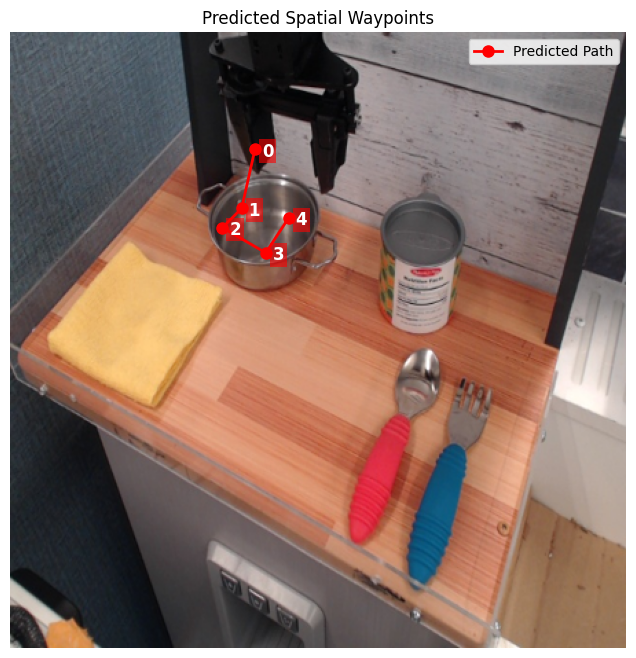

In [66]:
import matplotlib.pyplot as plt
import numpy as np

# Your image from the dataset
image = data['frames'][0]

# 1. Detach the tensor, move to CPU, and convert to numpy
# waypoints shape is [1, 5, 2], so we take [0] to get the (5, 2) array
waypoints_np = waypoints.detach().cpu().to(torch.float32).numpy()[0] 

# 2. Get image dimensions to denormalize the coordinates
# If it's a PIL Image:
if hasattr(image, 'size'):
    width, height = image.size
# If it's a numpy array or PyTorch tensor:
else:
    height, width = np.array(image).shape[:2]

# 3. Denormalize coordinates: [x, y] * [width, height]
x_coords = waypoints_np[:, 0] * width
y_coords = waypoints_np[:, 1] * height

# 4. Plot the image and overlay the waypoints
plt.figure(figsize=(10, 8))
plt.imshow(image)

# Draw the path (lines connecting the waypoints)
plt.plot(x_coords, y_coords, marker='o', color='red', markersize=8, linewidth=2, label='Predicted Path')

# Number each waypoint to see the sequence order (0 to 4)
for i, (x, y) in enumerate(zip(x_coords, y_coords)):
    plt.text(x + max(width*0.01, 5), y + max(height*0.01, 5), str(i), 
             color='white', fontsize=12, weight='bold',
             bbox=dict(facecolor='red', alpha=0.6, pad=2, edgecolor='none'))

plt.legend()
plt.axis('off') # Hide axes for cleaner look
plt.title('Predicted Spatial Waypoints')
plt.show()


In [67]:
data['assistant']

'[168, 434, 233, 499]'

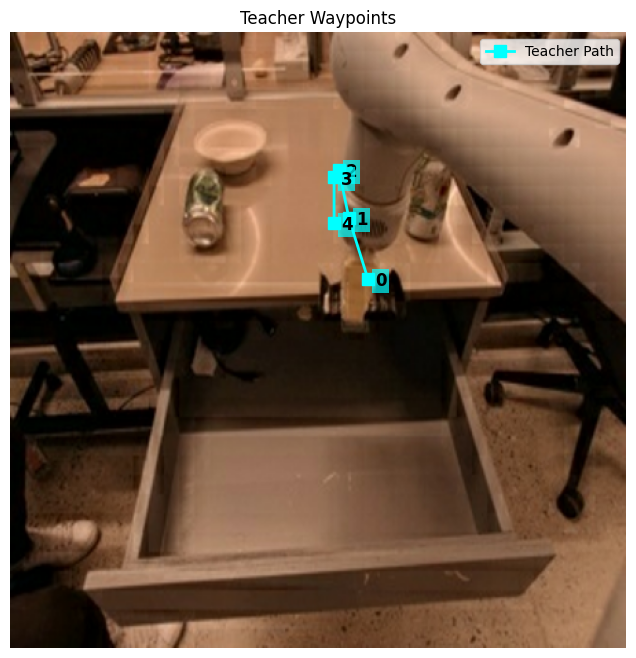

In [56]:
visualize_teacher_waypoints(image, [[580,400],[549,301],[533,223],[525,235],[525,309]])

In [31]:
import matplotlib.pyplot as plt
import numpy as np

def visualize_teacher_waypoints(image, waypoints_list):
    # Convert image to array to safely get height (h) and width (w)
    img_array = np.array(image)
    h, w = img_array.shape[:2]

    # Convert the list to a numpy array and normalize by 1000
    pts = np.array(waypoints_list, dtype=np.float32) / 1000.0

    # Scale the [0, 1] coordinates to the image's absolute pixels
    x_coords = pts[:, 0] * w
    y_coords = pts[:, 1] * h

    # Create the visualization
    plt.figure(figsize=(10, 8))
    plt.imshow(img_array)

    # Plot lines and markers
    plt.plot(x_coords, y_coords, marker='s', color='cyan', markersize=8, linewidth=2, label='Teacher Path')

    # Add step numbers (0 to 4) next to each waypoint
    for i, (x, y) in enumerate(zip(x_coords, y_coords)):
        plt.text(x + max(w * 0.01, 5), y + max(h * 0.01, 5), str(i), 
                 color='black', fontsize=12, weight='bold',
                 bbox=dict(facecolor='cyan', alpha=0.7, pad=2, edgecolor='none'))

    plt.legend()
    plt.axis('off')
    plt.title('Teacher Waypoints')
    plt.show()

In [68]:
print("Merging LoRA weights into base model...")
student.vlm = student.vlm.merge_and_unload()

Merging LoRA weights into base model...


In [69]:
save_dir = "merged_latent_student_619"
os.makedirs(save_dir, exist_ok=True)

In [70]:
print("Saving merged base model and processor...")
student.vlm.save_pretrained(save_dir)
processor.save_pretrained(save_dir)

Saving merged base model and processor...


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

['merged_latent_student_619/processor_config.json']

In [71]:
print("Saving custom spatial parameters...")
custom_weights = {
    "spatial_tokens": student.spatial_tokens.data.cpu(),
    "spatial_mlp": {k: v.cpu() for k, v in student.spatial_mlp.state_dict().items()}
}
torch.save(custom_weights, os.path.join(save_dir, "spatial_parameters.pt"))

Saving custom spatial parameters...


In [72]:
repo_id = "shreethar/LatentStudent-ckpt-619"  # <--- CHANGE THIS to your desired repo name
print(f"Pushing everything to {repo_id}...")

Pushing everything to shreethar/LatentStudent-ckpt-619...


In [73]:
import torch
import os
from huggingface_hub import HfApi, login

In [ ]:
api = HfApi(token = "")
api.create_repo(repo_id=repo_id, exist_ok=True, token = "")
api.upload_folder(
    folder_path=save_dir,
    repo_id=repo_id,
    commit_message="Upload fully merged LatentStudent model with spatial parameters",
)
print("Upload Complete!")

Processing Files (0 / 0): |          |  0.00B /  0.00B            

New Data Upload: |          |  0.00B /  0.00B            

Upload Complete!


In [63]:
stage1 = AutoModelForImageTextToText.from_pretrained(
    "shreethar/stage1_unsloth",
    dtype = torch.bfloat16,
    device_map = "cuda"
)

Loading weights:   0%|          | 0/723 [00:00<?, ?it/s]

In [80]:
output = stage1.generate(**input_ids, max_new_tokens = 4096)

KeyboardInterrupt: 

In [81]:
processor.tokenizer.decode(output[0])

"<|im_start|>user\n<|vision_start|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|i

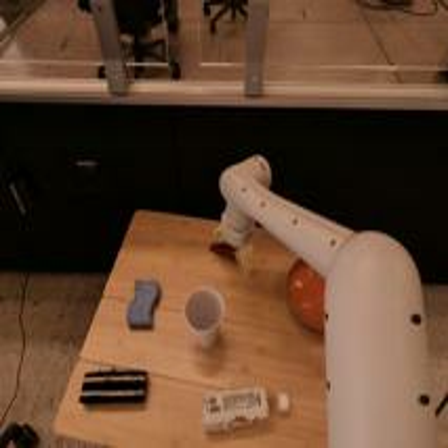

In [75]:
image